# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Abellana, Karl Gian
- _Student No._: 2024-09545
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

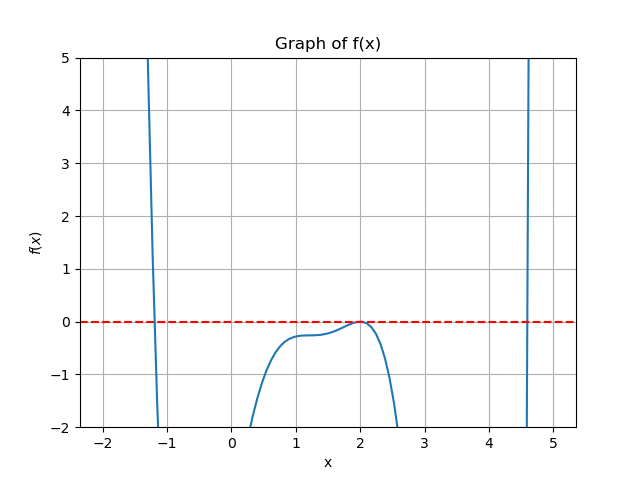

Figure 1. Plot of f(x)

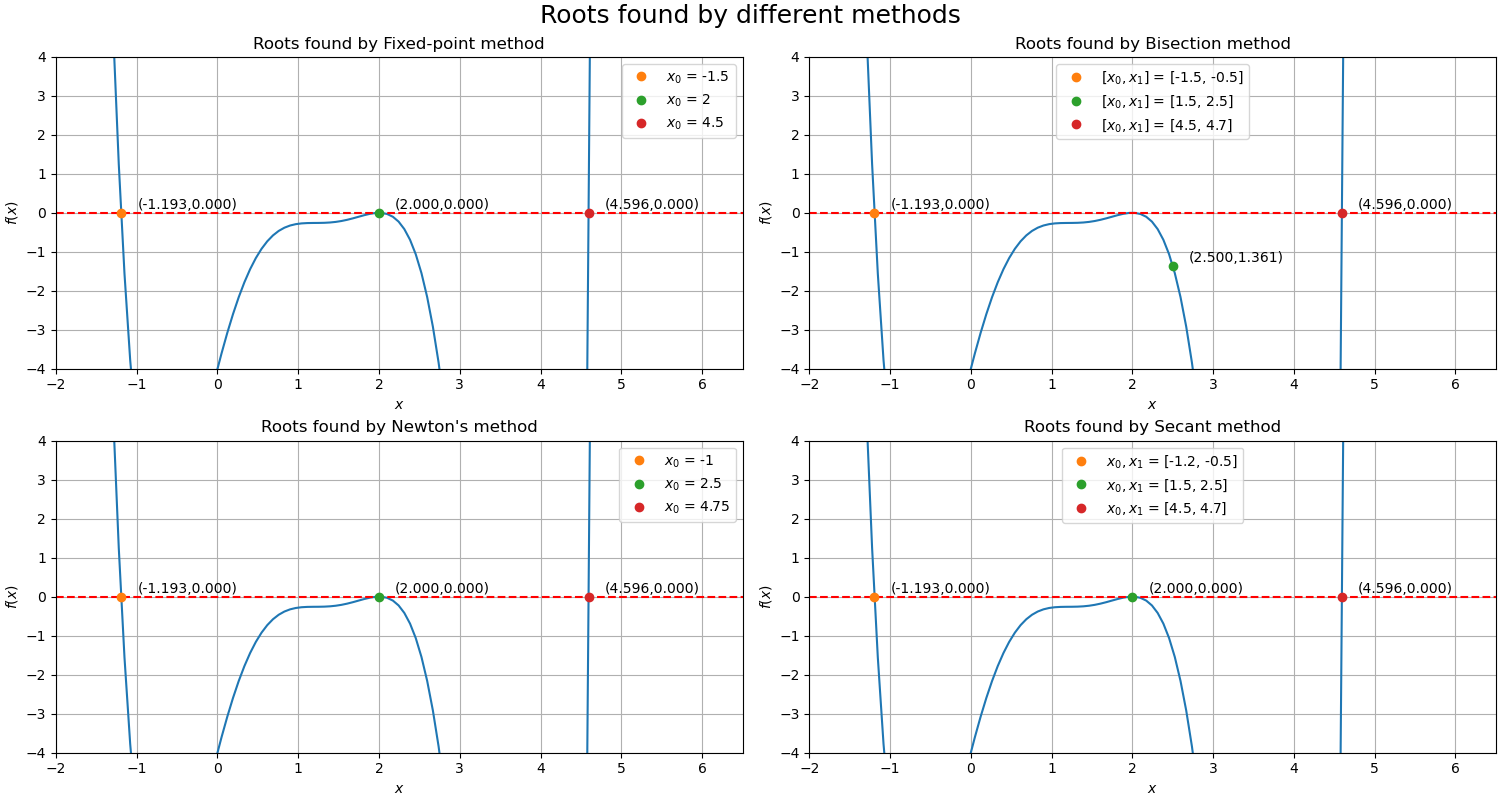

Figure 2. Roots found by different methods

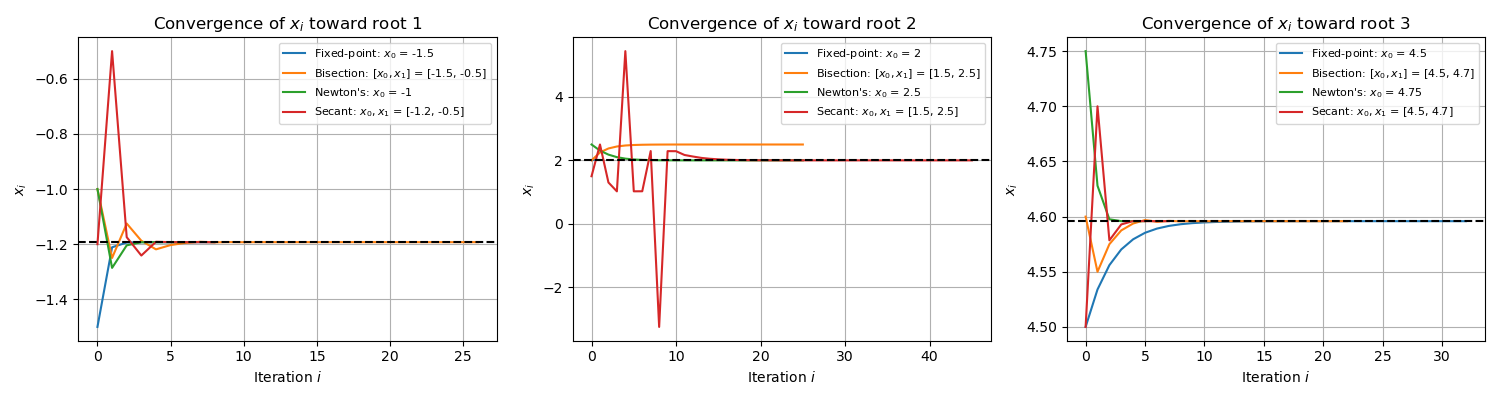
Figure 3. Convergence plot

### Report discussion

Figure 1 shows a zoomed-in plot of f(x) with three visible roots. The outer two cross the x-axis, while the middle root does not.

Figure 2 shows the roots found by each method. All methods agree except bisection on the second root. Since the curve does not cross the x-axis there, the Intermediate Value Theorem, assumed by the bisection method, says nothing about values outside $[f(x_0), f(x_1)]$. The algorithm falsely flags the root to be in $[x_2, x_1]$ every time, so it hugs the second guessing point.

Figure 3 shows how the guesses converge. Newton's method is fastest for all three roots. Fixed-point iteration slows as the root's slope gets steeper, while the secant method slows as the slope gets flatter, with oscillations from overshoots in the slope approximation. Bisection converges quickly when the guess is close to the root but fails in cases like the second root.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

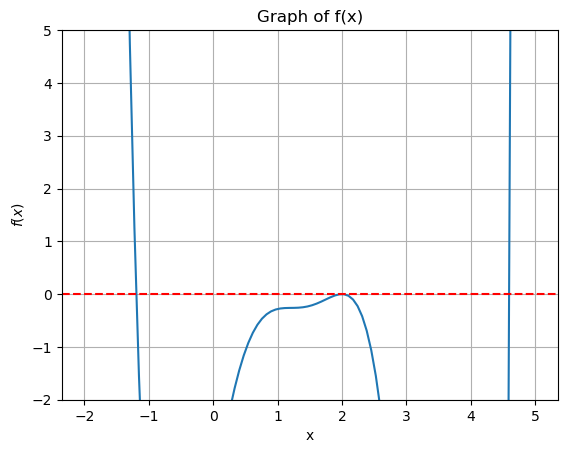

In [2]:
def f(x):
    return -(x**5) + 4*(x**4) - 4*(x**3) + (x**2)*np.exp(x) - 2*(x**2) - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

points = 100
xs = np.linspace(-2, 5, points, endpoint = True)
fxs = f(xs)

plt.plot(xs, fxs)
plt.ylim(-2, 5)
#plt.xlim(0,3)
plt.axhline(0, color="red", ls='--')
plt.xlabel("x")
plt.ylabel(r"$f(x)$")
plt.title("Graph of f(x)")
plt.grid()
plt.savefig("fx.png")
plt.show()

In [3]:
# Rewrite the function as g(x) s.t. x = g(x):

# We can guess where the roots are at from the graph. Massaging the equation gives us two ways to rewrite f(x).
def g_0(x):
    return np.cbrt(np.exp(x) - 2)

def g_1(x):
    return 2 # case when (x-2)^2 isn't 0 and the other term is!

def g_2(x):
    return np.log(x**3+2)


    
# Fixed-point method
def fixedPoint(func, x_old, k_max = 200, tol = 1.e-8): # k_max is how many steps we want to try
    history = [x_old] # storing iterations to plot convergence
    for k in range (1, k_max):
        # since the function is rewritten such that the roots are fixed-points, we grab a new x from the function
        x_new = func(x_old)

        # store every iteration so that we can plot the convergence
        history.append(x_new) 
        # and then we test how close they are
        x_diff = x_new-x_old

        # if they're really close such that its less than the tolerance, we end and this is now the root.
        if abs(x_diff/x_new) < tol:
            break

        # if it isn't, let the new x be the new guessing spot, if it converges, the x_old and x_new should converge, giving us the root.
        x_old = x_new

    else:
        # if it diverges (keeps looping), return None
        x_new = None

    return x_new, history

# stores results in dict so its easier to plot
results_fixed_point = {
    'method' : "Fixed-point iteration",
    'test_points' : [],
    'hist' : [],
    'roots' : []
}

test_ranges = ([g_0, -1.5], [g_1, 2], [g_2, 4.5])

for func, x_0 in test_ranges:
    root, hist = fixedPoint(func, x_0)
    results_fixed_point['roots'].append(root)
    results_fixed_point['hist'].append(hist)
    results_fixed_point['test_points'].append(f"$x_0$ = {x_0}")

In [4]:
# Bisection method
def bisection(func, x_0, x_1, k_max=200, tol=1.e-8):
    func_0 = func(x_0)
    history = [(x_0 + x_1) / 2]                # first midpoint estimate, for the convergence plot
    for k in range(1, k_max):

        # bisect and then test it against the function
        x_2 = (x_0 + x_1) / 2
        func_2 = func(x_2)

        # if their products are less than 0, that means one of them is negative
        # if negative, due to IVP, zero must be in between x_0 and x_2. set x_1 = x_2
        if func_0 * func_2 < 0:
            x_1 = x_2
        # otherwise, if positive, then zero must be in between x_2 and x_1. adjust left bound accordingly
        else:
            x_0, func_0 = x_2, func_2

        # bisect once more, this will be our guess
        x_2_new = (x_0 + x_1) / 2
        history.append(x_2_new)                # store every estimate
        x_diff = abs(x_2_new - x_2)

        # if the relative difference between x2 new and x2 is less than the tolerance, break, its the root
        if abs(x_diff / x_2_new) < tol:
            break

    else:
        # if it diverges (kees looping), return None
        x_2_new = None

    return x_2_new, history

# store results in dict so that it is easier to plot
results_bisection = {
    'method' : "Bisection",
    'test_points' : [],
    'hist' : [],
    'roots' : []
}

test_ranges_bisection = ([-1.5, -0.5], [1.5, 2.5], [4.5, 4.7])

for a, b in test_ranges_bisection:
    root, hist = bisection(f, a, b)
    results_bisection['roots'].append(root)
    results_bisection['hist'].append(hist)
    results_bisection['test_points'].append(f"$[x_0, x_1]$ = [{a}, {b}]")

In [5]:
# Newton's method

# we have to define the derivative of our function
def df(x):
    return -5*(x**4) + 16*(x**3) - 12*(x**2) + (x**2 - 2*x) * np.exp(x) - 4*x + 8

def newton(func, dfunc, x_old, k_max = 200, tol = 1e-8):
    history = [x_old]                          # store the initial guess too
    for k in range(1, k_max):
        # rise divided by slope is run, so we're getting x_new from subtracting horizontally from x_old in the direction of slope
        x_new = x_old - func(x_old) / dfunc(x_old)
        history.append(x_new)                  # store every iterate

        # if the relative difference between x_new and x_old is less than tolerance, end the loop and lfg
        if abs((x_new - x_old) / x_new) < tol:
            break
        x_old = x_new

    # if it diverges (keeps looping), return None
    else:
        x_new = None
    return x_new, history

# store results in dict so its easier to plot
results_newton = {
    'method' : "Newton's",
    'test_points' : [],
    'hist' : [],
    'roots' : []
}

test_ranges_newton = [-1, 2.5, 4.75]

for x_0 in test_ranges_newton:
    root, hist = newton(f, df, x_0)
    results_newton['roots'].append(root)
    results_newton['hist'].append(hist)
    results_newton['test_points'].append(f"$x_0$ = {x_0}")

In [6]:
# Secant method
def secant(func, x_0, x_1, k_max = 200, tol = 1.e-8):
    history = [x_0, x_1]                       # both initial guesses, for the convergence plot
    f_0 = func(x_0)
    for k in range(1, k_max):
        f_1 = func(x_1)
        # similar to newton's method, but instead of using the analytic derivative to get the slope,
        # the slope is calculated using the the two point slope form
        ratio = (x_1 - x_0) / (f_1 - f_0)
        x_2 = x_1 - f_1 * ratio
        history.append(x_2)                    # store every iterate

        x_diff = abs(x_2 - x_1)
        x_0, x_1 = x_1, x_2
        f_0 = f_1

        # if relative difference less than tolerance, root is found
        if abs(x_diff / x_2) < tol:
            break

    # if diverges (keeps looping), return None
    else:
        x_2 = None

    return x_2, history

results_secant = {
    'method' : 'Secant',
    'test_points' : [],
    'hist' : [],
    'roots' : []
}

test_ranges_secant = ([-1.2, -0.5], [1.5, 2.5], [4.5, 4.7])

for a, b in test_ranges_secant:
    root, hist = secant(f, a, b)
    results_secant['roots'].append(root)
    results_secant['test_points'].append(f"$x_0, x_1$ = [{a}, {b}]")
    results_secant['hist'].append(hist)

----------------------
Method: Fixed-point iteration
Root 0: -1.192685765190788
Root 1: 2
Root 2: 4.595863504338853
----------------------
Method: Bisection
Root 0: -1.1926857605576515
Root 1: 2.499999985098839
Root 2: 4.595863556861877
----------------------
Method: Newton's
Root 0: -1.1926857650225988
Root 1: 2.0000000485107754
Root 2: 4.595863564922456
----------------------
Method: Secant
Root 0: -1.1926857650225986
Root 1: 1.999999977513282
Root 2: 4.595863564922455


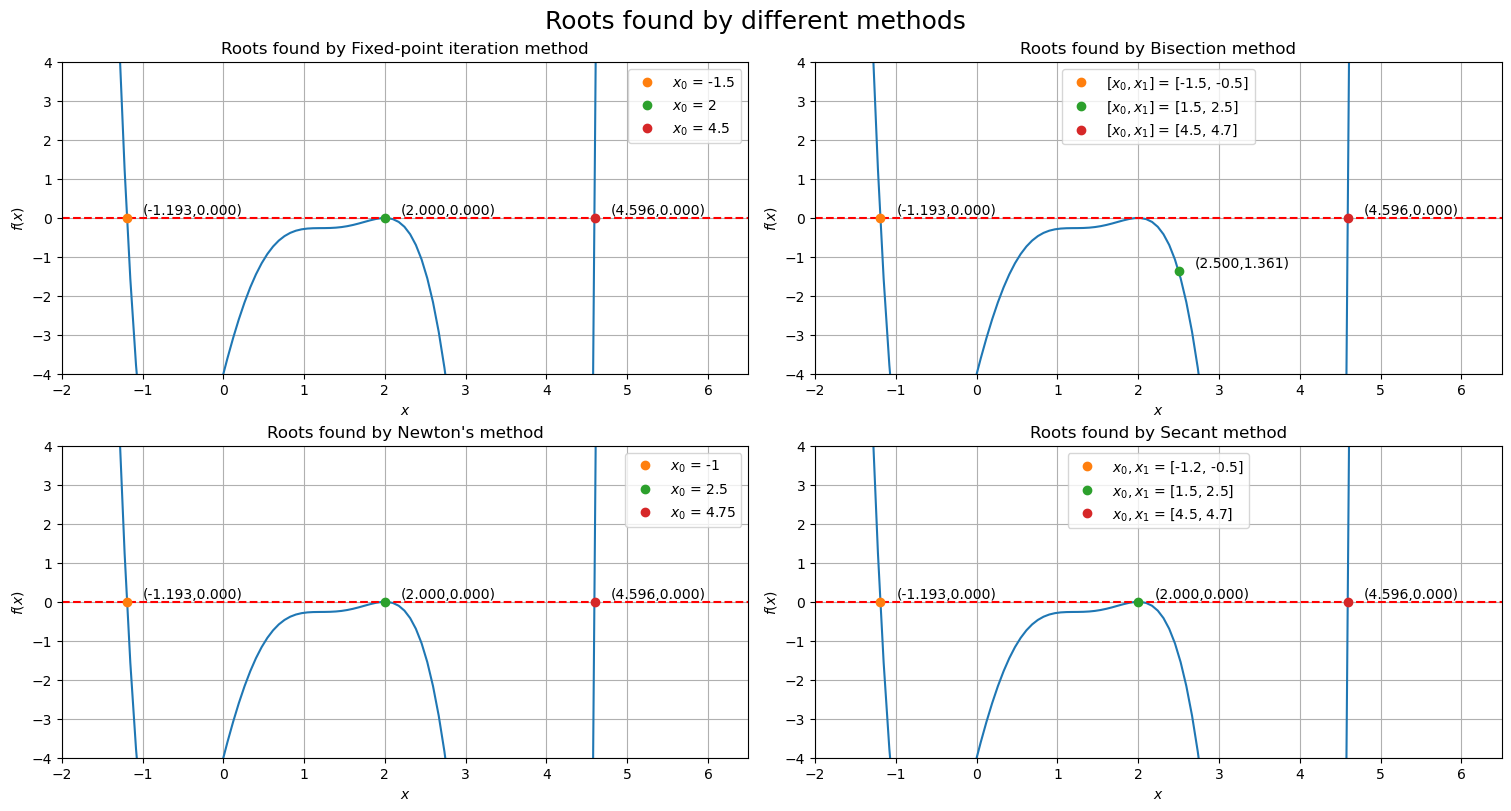

In [18]:
# plotting everything together in one fig

results = [results_fixed_point,
               results_bisection,
               results_newton,
               results_secant]

fig, ax = plt.subplots(2, 2, figsize=(15,8), constrained_layout = True)

counter = 0
for i in range(2):
    counter += i
    for j in range(2):
        counter += j
        ax[i][j].plot(xs,fxs)
        ax[i][j].axhline(0, color="red", ls='--')
        ax[i][j].grid()
        ax[i][j].set_xlim(-2, 6.5)
        ax[i][j].set_ylim(-4,4)
        ax[i][j].set_xlabel(r"$x$")
        ax[i][j].set_ylabel(r"$f(x)$")
        ax[i][j].set_title(f"Roots found by {results[counter]['method']} method")

        # can use zip to iterate through two keys at the same time
        for k, points in zip(results[counter]['roots'], results[counter]['test_points']):
            ax[i][j].plot(k, f(k), 'o', label = points)
            ax[i][j].text(k+0.2, f(k) + 0.2, f'({k:.3f},{abs(f(k)):.3f})', verticalalignment="center")
        ax[i][j].legend()

fig.suptitle("Roots found by different methods", fontsize = 18)
plt.savefig("roots.png")

# printing the actual roots found
for result in results:
    print('----------------------')
    print('Method: ' + result['method'])
    for m in range(len(result['roots'])):
        print("Root "+str(m)+f": {result['roots'][m]}")

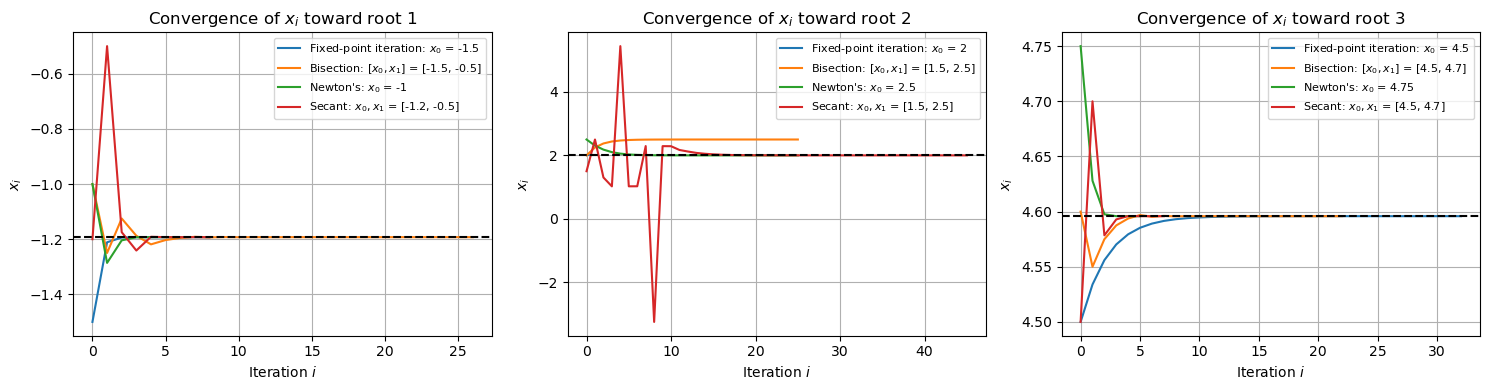

In [8]:
# Convergence plots:
n_roots = 3
fig, ax = plt.subplots(1, 3, figsize=(15,4))

for j in range(n_roots):

    root = results[0]['roots'][j]
    
    for method in results:
        line, = ax[j].plot(np.arange(len(method['hist'][j])), method['hist'][j], '-', ms=4, label=method['method'] +": "+ method['test_points'][j])
            
    ax[j].axhline(root, color="black", ls='--')
    ax[j].set_xlabel("Iteration $i$")
    ax[j].set_ylabel(r"$x_i$")
    ax[j].set_title(f"Convergence of $x_i$ toward root {j+1}")
    ax[j].grid()
    ax[j].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"convergence.png")
plt.show()

#### Problem 1 code summary
---

Making use of four different methods to find the roots. All methods are essentially iterative, so ```for else``` loops are used. The else condition runs if the code keeps looping without hitting break, which means the guessed value is diverging away. The ```fixedPoint()``` function uses a method that starts with an initial guess near the root, using a fixed-point function we can call a new point that should converge to the root. ```bisection()``` function uses two initial guesses the bounds the root, and gets the value in the middle and repeats until it gets close to the root. Both ```newton()``` and ```secant()``` functions use derivatives to get the slope to point the initial guess towards the root. The results were stored in a dictionary so that it is easier to plot using ```matplotlib```. 